# Karachi Education Survey - Executive Summary

## Overview
Analysis of 34 student responses exploring study habits, academic challenges, and wellbeing concerns in Karachi schools.

---

In [1]:
import sys
sys.path.insert(0, '../scripts')
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load data
df = load_survey_data()
df = clean_survey_data(df)
print(f"✓ Survey Data Loaded: {len(df)} responses")

✓ Survey Data Loaded: 50 responses


## Key Findings at a Glance

### Student Demographics

In [2]:
# Demographics snapshot
print("="*60)
print("STUDENT DEMOGRAPHICS")
print("="*60)
print(f"\n📊 Total Students: {len(df)}")
print(f"📅 Age Range: {df['age'].min():.0f} - {df['age'].max():.0f} years (avg: {df['age'].mean():.1f})")
print(f"\n👥 Gender Breakdown:")
gender_dist = df['gender'].value_counts()
for gender, count in gender_dist.items():
    pct = (count / len(df)) * 100
    print(f"   • {gender}: {count} ({pct:.1f}%)")
    
print(f"\n🎓 Grade Distribution:")
grade_dist = df['grade/class'].value_counts()
for grade, count in grade_dist.items():
    pct = (count / len(df)) * 100
    print(f"   • {grade}: {count} ({pct:.1f}%)")

STUDENT DEMOGRAPHICS

📊 Total Students: 50
📅 Age Range: 15 - 48 years (avg: 19.2)

👥 Gender Breakdown:
   • Male: 30 (60.0%)
   • Female: 19 (38.0%)
   • Prefer Not Say: 1 (2.0%)

🎓 Grade Distribution:
   • 11: 17 (34.0%)
   • 12: 14 (28.0%)
   • Under-Grad (Bachelors): 11 (22.0%)
   • Post-grad (Masters): 4 (8.0%)
   • 10: 3 (6.0%)
   • 9: 1 (2.0%)


### Study Patterns

In [3]:
# Study habits snapshot
print("\n" + "="*60)
print("STUDY HABITS")
print("="*60)

# Study hours
print(f"\n⏰ Daily Study Hours:")
order = ['Less than 1 hour', '1–2 hours', '2–4 hours', 'More than 4 hours']
hours_dist = df['average_hours_spent_studying_per_day'].value_counts()
for hour_range in order:
    count = hours_dist.get(hour_range, 0)
    pct = (count / len(df)) * 100 if count > 0 else 0
    print(f"   • {hour_range}: {count} ({pct:.1f}%)")

# Most common study methods
study_methods = {}
for methods_str in df['preferred_study_method'].dropna():
    if isinstance(methods_str, str):
        methods = [m.strip() for m in methods_str.split(';')]
        for m in methods:
            study_methods[m] = study_methods.get(m, 0) + 1

print(f"\n📚 Top Study Methods:")
sorted_methods = sorted(study_methods.items(), key=lambda x: x[1], reverse=True)[:3]
for method, count in sorted_methods:
    pct = (count / len(df)) * 100
    print(f"   • {method}: {count} ({pct:.1f}%)")


STUDY HABITS

⏰ Daily Study Hours:
   • Less than 1 hour: 18 (36.0%)
   • 1–2 hours: 13 (26.0%)
   • 2–4 hours: 13 (26.0%)
   • More than 4 hours: 6 (12.0%)

📚 Top Study Methods:
   • Self-study: 41 (82.0%)
   • Online tutorials: 14 (28.0%)
   • Coaching classes: 13 (26.0%)


### Challenging Subjects

In [4]:
# Challenging subjects
challenging_subjects = {}
for subjects_str in df['subject(s)_you_find_most_challenging'].dropna():
    if isinstance(subjects_str, str):
        subjects = [s.strip() for s in subjects_str.split(';')]
        for s in subjects:
            if s and len(s) > 2:
                if 'math' in s.lower():
                    challenging_subjects['Math'] = challenging_subjects.get('Math', 0) + 1
                elif 'science' in s.lower() or 'physics' in s.lower() or 'chem' in s.lower() or 'bio' in s.lower():
                    challenging_subjects['Science'] = challenging_subjects.get('Science', 0) + 1
                elif 'urdu' in s.lower() or 'islamiat' in s.lower() or 'pakistan' in s.lower():
                    challenging_subjects['Languages/Urdu'] = challenging_subjects.get('Languages/Urdu', 0) + 1
                else:
                    challenging_subjects[s] = challenging_subjects.get(s, 0) + 1

print("\n" + "="*60)
print("CHALLENGING SUBJECTS")
print("="*60)
print(f"\n📖 Most Challenging:")
sorted_subjects = sorted(challenging_subjects.items(), key=lambda x: x[1], reverse=True)
for subject, count in sorted_subjects:
    pct = (count / len(df)) * 100
    print(f"   • {subject}: {count} ({pct:.1f}%)")


CHALLENGING SUBJECTS

📖 Most Challenging:
   • Math: 26 (52.0%)
   • Science: 21 (42.0%)
   • Languages/Urdu: 3 (6.0%)
   • Economics: 1 (2.0%)
   • Research methodologies, comparative politics, international political economy, international law, diplomacy, strategic studies, and international security studies.: 1 (2.0%)


### Student Wellbeing

In [5]:
# Find wellbeing columns
margin_col = [col for col in df.columns if 'marginalized' in col.lower()][0]
substance_col = [col for col in df.columns if 'tobacco' in col.lower() or 'substance' in col.lower()][0]

print("\n" + "="*60)
print("STUDENT WELLBEING")
print("="*60)

# Marginalization
print(f"\n⚠️  Marginalization/Discrimination:")
margin_counts = df[margin_col].value_counts()
for status in ['Never', 'Rarely', 'Sometimes', 'Often']:
    count = margin_counts.get(status, 0)
    pct = (count / len(df)) * 100
    print(f"   • {status}: {count} ({pct:.1f}%)")

# Substance use
print(f"\n🚨 Substance Use (tobacco, alcohol, or other):")
substance_counts = df[substance_col].value_counts()
for status in ['No', 'Sometimes', 'Yes']:
    count = substance_counts.get(status, 0)
    pct = (count / len(df)) * 100
    print(f"   • {status}: {count} ({pct:.1f}%)")


STUDENT WELLBEING

⚠️  Marginalization/Discrimination:
   • Never: 14 (28.0%)
   • Rarely: 6 (12.0%)
   • Sometimes: 20 (40.0%)
   • Often: 10 (20.0%)

🚨 Substance Use (tobacco, alcohol, or other):
   • No: 34 (68.0%)
   • Sometimes: 2 (4.0%)
   • Yes: 14 (28.0%)


---

## Visualizations

### Demographics Charts

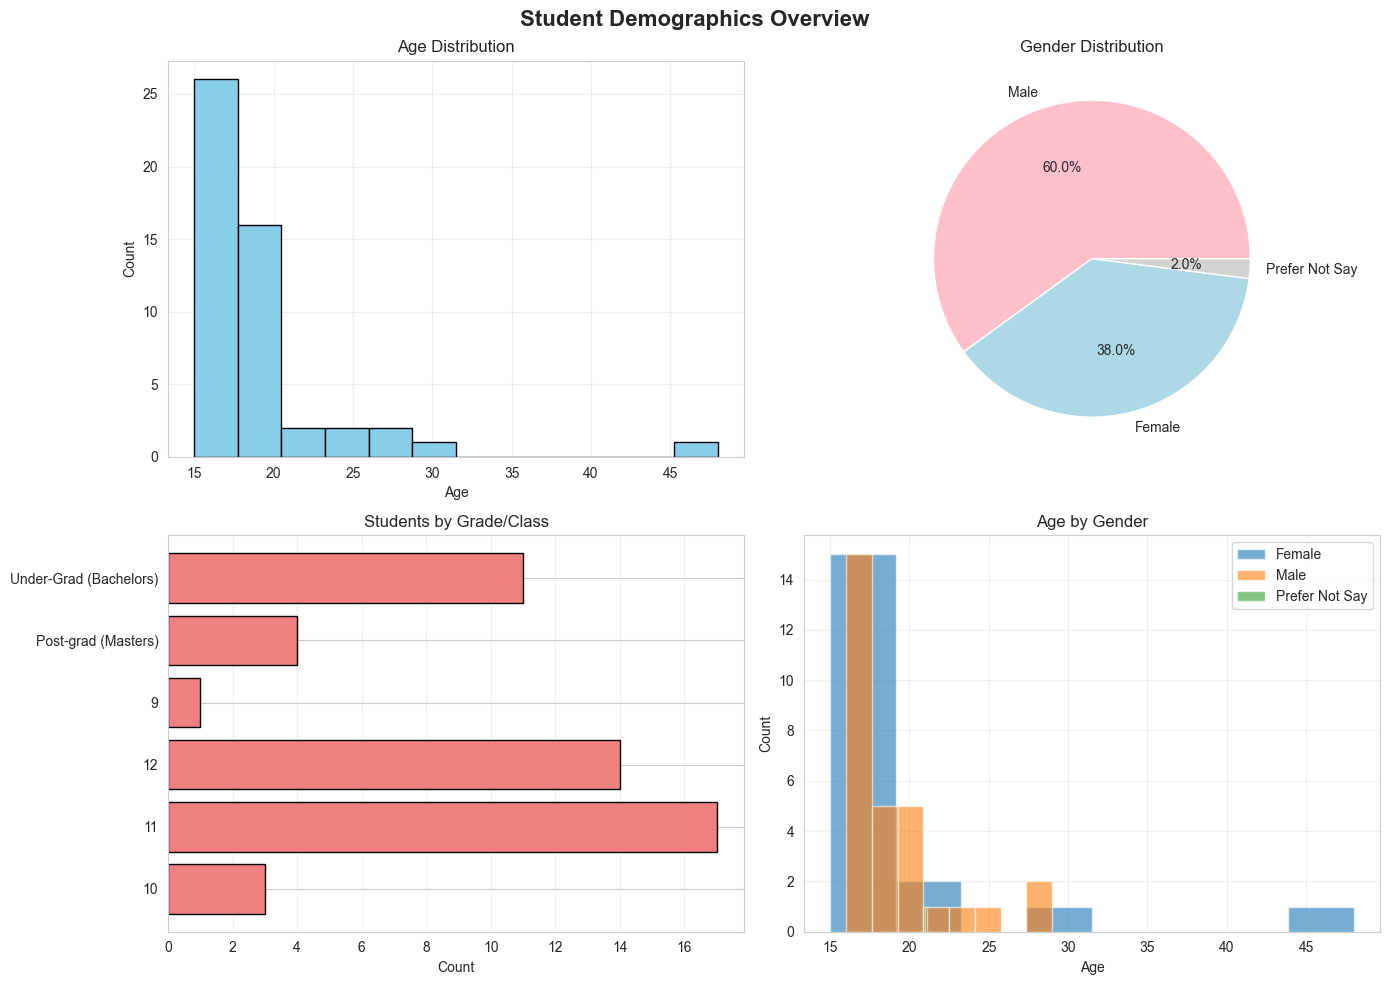

✓ Chart saved to visuals/01_demographics_overview.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Demographics Overview', fontsize=16, fontweight='bold')

# Age histogram
axes[0, 0].hist(df['age'].dropna(), bins=12, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].grid(alpha=0.3)

# Gender pie
gender_counts = df['gender'].value_counts()
axes[0, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['pink', 'lightblue', 'lightgray'][:len(gender_counts)])
axes[0, 1].set_title('Gender Distribution')

# Grade distribution
grade_counts = df['grade/class'].value_counts().sort_index()
axes[1, 0].barh(grade_counts.index, grade_counts.values, color='lightcoral', edgecolor='black')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Students by Grade/Class')
axes[1, 0].grid(alpha=0.3, axis='x')

# Age by gender
for gender in df['gender'].unique():
    if pd.notna(gender):
        ages = df[df['gender'] == gender]['age'].dropna()
        axes[1, 1].hist(ages, alpha=0.6, label=str(gender), bins=8)
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Age by Gender')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/01_demographics_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/01_demographics_overview.png")

### Study Habits Charts

C:\Users\Husayn\AppData\Local\Temp\ipykernel_12488\1366940170.py:61: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


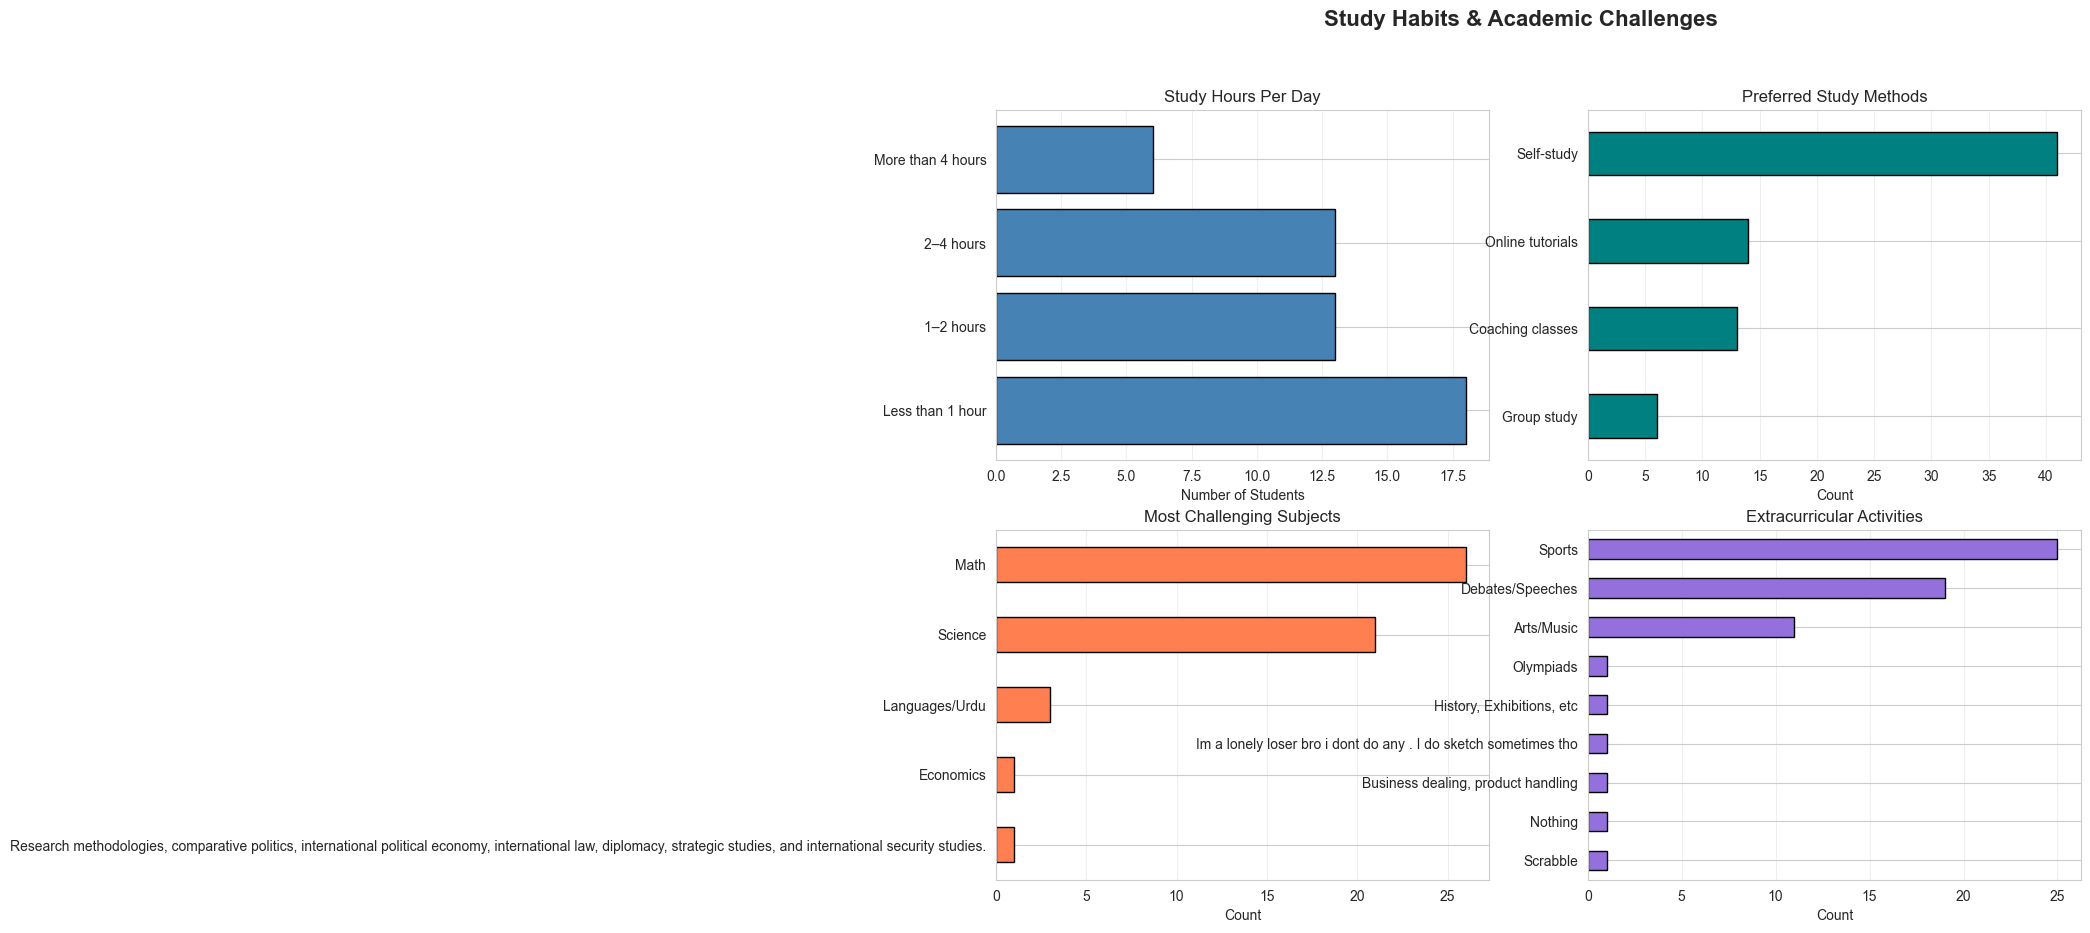

✓ Chart saved to visuals/02_study_habits_overview.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Study Habits & Academic Challenges', fontsize=16, fontweight='bold')

# Study hours
order = ['Less than 1 hour', '1–2 hours', '2–4 hours', 'More than 4 hours']
hours_counts = df['average_hours_spent_studying_per_day'].value_counts()
hours_ordered = [hours_counts.get(h, 0) for h in order]
axes[0, 0].barh(order, hours_ordered, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Students')
axes[0, 0].set_title('Study Hours Per Day')
axes[0, 0].grid(alpha=0.3, axis='x')

# Study methods
study_methods = {}
for methods_str in df['preferred_study_method'].dropna():
    if isinstance(methods_str, str):
        methods = [m.strip() for m in methods_str.split(';')]
        for m in methods:
            study_methods[m] = study_methods.get(m, 0) + 1
methods_df = pd.Series(study_methods).sort_values()
methods_df.plot(kind='barh', color='teal', edgecolor='black', ax=axes[0, 1])
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Preferred Study Methods')
axes[0, 1].grid(alpha=0.3, axis='x')

# Challenging subjects
challenging_subjects = {}
for subjects_str in df['subject(s)_you_find_most_challenging'].dropna():
    if isinstance(subjects_str, str):
        subjects = [s.strip() for s in subjects_str.split(';')]
        for s in subjects:
            if s and len(s) > 2:
                if 'math' in s.lower():
                    challenging_subjects['Math'] = challenging_subjects.get('Math', 0) + 1
                elif 'science' in s.lower() or 'physics' in s.lower() or 'chem' in s.lower() or 'bio' in s.lower():
                    challenging_subjects['Science'] = challenging_subjects.get('Science', 0) + 1
                elif 'urdu' in s.lower() or 'islamiat' in s.lower() or 'pakistan' in s.lower():
                    challenging_subjects['Languages/Urdu'] = challenging_subjects.get('Languages/Urdu', 0) + 1
                else:
                    challenging_subjects[s] = challenging_subjects.get(s, 0) + 1
subjects_df = pd.Series(challenging_subjects).sort_values()
subjects_df.plot(kind='barh', color='coral', edgecolor='black', ax=axes[1, 0])
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Most Challenging Subjects')
axes[1, 0].grid(alpha=0.3, axis='x')

# Activities
activities = {}
for activities_str in df['extra-curricular_activities_you_participate_in'].dropna():
    if isinstance(activities_str, str) and activities_str.strip():
        acts = [a.strip() for a in activities_str.split(';')]
        for a in acts:
            if a:
                activities[a] = activities.get(a, 0) + 1
activities_df = pd.Series(activities).sort_values()
activities_df.plot(kind='barh', color='mediumpurple', edgecolor='black', ax=axes[1, 1])
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Extracurricular Activities')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../visuals/02_study_habits_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/02_study_habits_overview.png")

### Wellbeing Charts

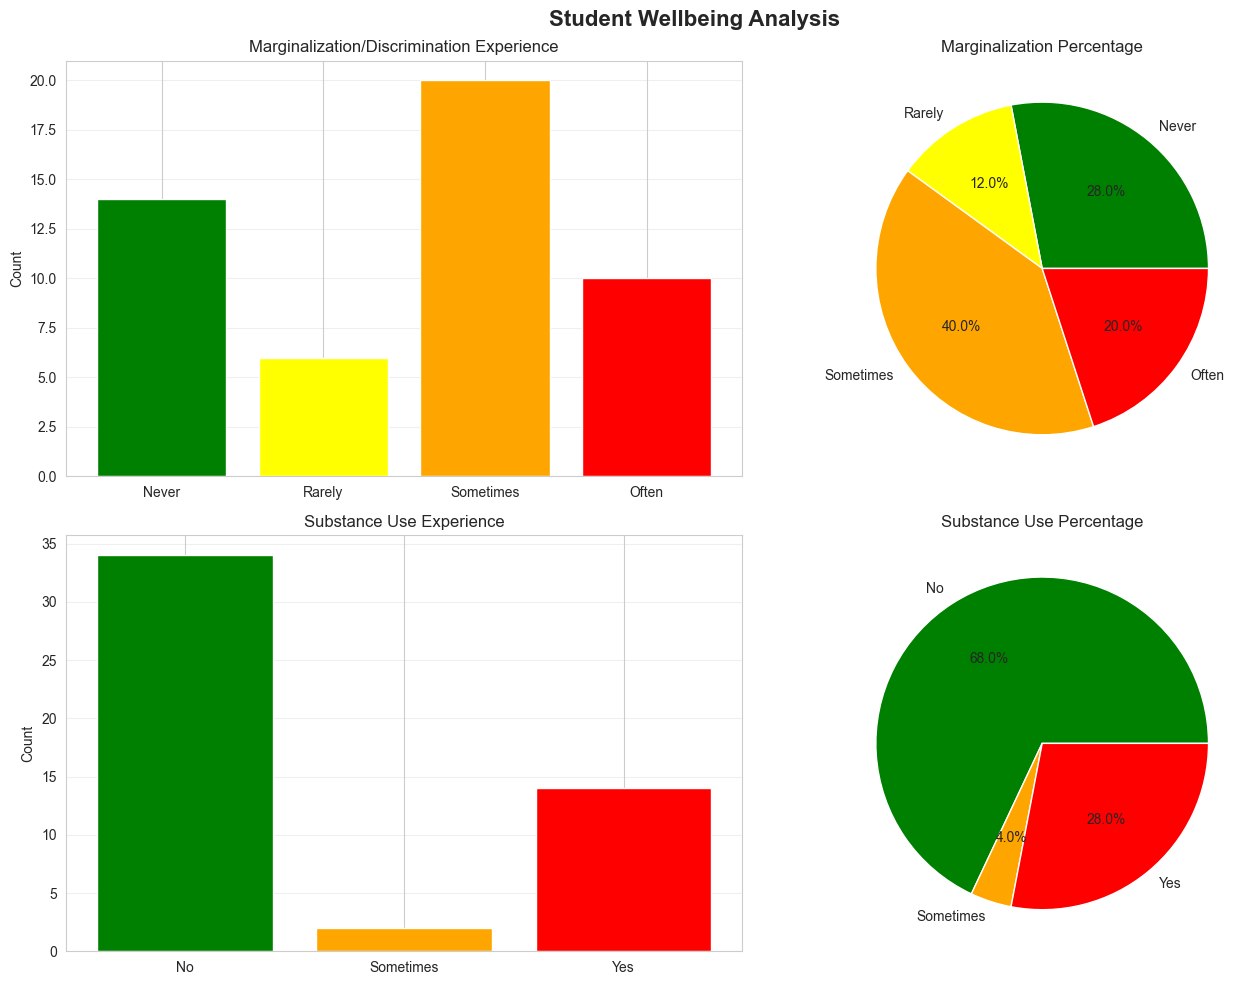

✓ Chart saved to visuals/03_wellbeing_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Wellbeing Analysis', fontsize=16, fontweight='bold')

# Marginalization bar
margin_counts = df[margin_col].value_counts()
order = ['Never', 'Rarely', 'Sometimes', 'Often']
margin_ordered = [margin_counts.get(m, 0) for m in order]
axes[0, 0].bar(order, margin_ordered, color=['green', 'yellow', 'orange', 'red'])
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Marginalization/Discrimination Experience')
axes[0, 0].grid(alpha=0.3, axis='y')

# Marginalization pie
axes[0, 1].pie(margin_ordered, labels=order, autopct='%1.1f%%', colors=['green', 'yellow', 'orange', 'red'])
axes[0, 1].set_title('Marginalization Percentage')

# Substance use bar
substance_counts = df[substance_col].value_counts()
order = ['No', 'Sometimes', 'Yes']
substance_ordered = [substance_counts.get(s, 0) for s in order]
axes[1, 0].bar(order, substance_ordered, color=['green', 'orange', 'red'])
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Substance Use Experience')
axes[1, 0].grid(alpha=0.3, axis='y')

# Substance use pie
axes[1, 1].pie(substance_ordered, labels=order, autopct='%1.1f%%', colors=['green', 'orange', 'red'])
axes[1, 1].set_title('Substance Use Percentage')

plt.tight_layout()
plt.savefig('../visuals/03_wellbeing_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/03_wellbeing_overview.png")

---

## Recommendations

### Based on the Survey Data:

1. **Study Support**
   - Math and Science are challenging for most students
   - Consider tutoring programs or study groups for these subjects

2. **Study Environment**
   - Mix of study methods used (Self-study, Online tutorials, Coaching)
   - Provide flexible learning options for different preferences

3. **Wellbeing**
   - Monitor students experiencing marginalization
   - Implement inclusivity programs
   - Address substance use concerns through awareness programs

4. **Extracurricular**
   - Strong engagement in sports and other activities
   - Continue supporting diverse activity options

---

## Next Steps

- Share findings with school administration
- Develop targeted interventions based on identified challenges
- Consider follow-up survey for specific areas
- Monitor wellbeing metrics regularly